# 1. Import

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
from pathlib import Path

BASE_DIR = Path.cwd()

DATA_PATH = BASE_DIR / "data" / "LinearPGG_4P_ExperimentalData.csv"

print(DATA_PATH)

c:\Users\GU\Documents\GitHub\asymmetric-public-goods-replication\data\LinearPGG_4P_ExperimentalData.csv


In [104]:
data = pd.read_csv(DATA_PATH)

# 2. Validation

In [105]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12480 entries, 0 to 12479
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Treatment       12480 non-null  object
 1   Session         12480 non-null  int64 
 2   GroupID         12480 non-null  int64 
 3   PlayerID        12480 non-null  int64 
 4   GlobalPlayerID  12480 non-null  int64 
 5   Round           12480 non-null  int64 
 6   Contribution    12480 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 682.6+ KB


In [106]:
data.dtypes,
data.info(),
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12480 entries, 0 to 12479
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Treatment       12480 non-null  object
 1   Session         12480 non-null  int64 
 2   GroupID         12480 non-null  int64 
 3   PlayerID        12480 non-null  int64 
 4   GlobalPlayerID  12480 non-null  int64 
 5   Round           12480 non-null  int64 
 6   Contribution    12480 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 682.6+ KB


,Session,GroupID,PlayerID,GlobalPlayerID,Round,Contribution
count,12480.00000,12480.000000,12480.000000,12480.000000,12480.000000,12480.000000
mean,1.50000,26.525641,2.500000,104.602564,10.500000,15.817788
std,0.50002,15.053267,1.118079,60.223446,5.766512,11.485985
min,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.00000,13.750000,1.750000,52.750000,5.750000,7.000000
50%,1.50000,26.500000,2.500000,104.500000,10.500000,12.000000
75%,2.00000,39.250000,3.250000,156.250000,15.250000,24.000000
max,2.00000,54.000000,4.000000,216.000000,20.000000,36.000000


In [107]:
data.duplicated(subset=["Treatment","GroupID","PlayerID","Round"]).sum()

0

In [108]:
data_Session_different= data.groupby(["Treatment","GroupID"])["Session"].nunique()
(data_Session_different > 1).any()

False

In [109]:
data.duplicated(subset=["GlobalPlayerID","Round"]).sum()

8160

In [110]:
data.duplicated(subset=["Treatment","GlobalPlayerID","Round"]).sum()

0

In [111]:
data["Treatment"].unique()

array(['FE', 'AI', 'MI'], dtype=object)

In [112]:
data.groupby("Treatment")["GroupID"].agg(["min", "max"])

,min,max
Treatment,,
AI,1,52
FE,1,50
MI,1,54


In [113]:
expected_ids = {
    "AI": set(range(1, 53)),
    "FE": set(range(1, 51)),
    "MI": set(range(1, 55))
}
for treatment, group in data.groupby("Treatment"):
    actual_ids = set(group["GroupID"].unique())
    print(treatment, actual_ids==expected_ids[treatment])

AI True
FE True
MI True


In [114]:
expected_Slayerids = set(range(1,5))
bad_groups = []
for groupid, group in data.groupby(["Treatment","GroupID"]):
    actual_ids = set(group["PlayerID"]. unique())
    check=actual_ids==expected_Slayerids
    if check==False:
        bad_groups.append([groupid, check])
print(bad_groups)

[]


In [115]:
treatmentplayer_range = []
for playerkey, group in data.groupby(["Treatment","PlayerID"]):
    Contribution_range = group["Contribution"].agg(["min","max"])
    treatmentplayer_range.append([playerkey, Contribution_range])
print(treatmentplayer_range)

[[('AI', 1), min     0
max    36
Name: Contribution, dtype: int64], [('AI', 2), min     0
max    36
Name: Contribution, dtype: int64], [('AI', 3), min     0
max    12
Name: Contribution, dtype: int64], [('AI', 4), min     0
max    12
Name: Contribution, dtype: int64], [('FE', 1), min     0
max    24
Name: Contribution, dtype: int64], [('FE', 2), min     0
max    24
Name: Contribution, dtype: int64], [('FE', 3), min     0
max    24
Name: Contribution, dtype: int64], [('FE', 4), min     0
max    24
Name: Contribution, dtype: int64], [('MI', 1), min     0
max    36
Name: Contribution, dtype: int64], [('MI', 2), min     0
max    36
Name: Contribution, dtype: int64], [('MI', 3), min     0
max    12
Name: Contribution, dtype: int64], [('MI', 4), min     0
max    12
Name: Contribution, dtype: int64]]


In [116]:
max_contribution = {
    ('AI', 1): 36,
    ('AI', 2): 36,
    ('AI', 3): 12,
    ('AI', 4): 12,
    ('FE', 1): 24,
    ('FE', 2): 24,
    ('FE', 3): 24,
    ('FE', 4): 24,
    ('MI', 1): 36,
    ('MI', 2): 36,
    ('MI', 3): 12,
    ('MI', 4): 12,
}
treatmentplayer_range_validation= []
for playerkey_validation, group in data.groupby(["Treatment","PlayerID"]):
    check = group["Contribution"].between(0,max_contribution[playerkey_validation]).all()
    if not check:
        treatmentplayer_range_validation.append([playerkey_validation, check])
print(treatmentplayer_range_validation)

[]


In [117]:
expected_rounds = set(range(1,21))
bad_participant_key = []
for participant_key, group in data.groupby(["Treatment","GroupID","PlayerID"]):
    actual_rounds = set(group["Round"].unique ())
    check=actual_rounds==expected_rounds
    if check==False:
        bad_participant_key.append([participant_key, check])
print(bad_participant_key)

[]


In [118]:
expected_playerids = set(range(1,5))
bad_groups_round = []
for groupid_round, group in data.groupby(["Treatment","GroupID","Round"]):
    actual_ids_round = set(group["PlayerID"]. unique())
    check=actual_ids_round==expected_playerids
    if check==False:
        bad_groups_round.append([groupid_round, check])
print(bad_groups_round)

[]


In [119]:
keys = ["Treatment", "Session", "GroupID", "PlayerID", "Round"]
assert not data.duplicated(keys).any(),"keys重复"
assert not data[keys + ["Contribution"]].isna().any().any(),"缺失Contribution"



# 3. Variable Construction

Individual relative contribution
Endowment
group relative contribution
Effective contribution / payoff

In [120]:
Endowment = {
    ('AI', 1): 36,
    ('AI', 2): 36,
    ('AI', 3): 12,
    ('AI', 4): 12,
    ('FE', 1): 24,
    ('FE', 2): 24,
    ('FE', 3): 24,
    ('FE', 4): 24,
    ('MI', 1): 36,
    ('MI', 2): 36,
    ('MI', 3): 12,
    ('MI', 4): 12,
}

data["Endowment"] =data[["Treatment", "PlayerID"]].apply(tuple, axis=1).map(Endowment)
data["Endowment"].isna().sum()


data["RelativeContribution"] = data["Contribution"] / data["Endowment"]
data_group_relative_contribution = (
    data.groupby(
        ["Treatment", "GroupID", "Round"]
    )
    .apply(
        lambda x:
        x["Contribution"].sum()
        /
        x["Endowment"].sum()
    )
    .reset_index(name="GroupRelativeContribution")
)

data = data.merge(
    data_group_relative_contribution,
    how="left",
    on=["Treatment", "GroupID", "Round"]
)

Productivity = {
    ('AI', 1): 3.8,
    ('AI', 2): 3.8,
    ('AI', 3): 2.6,
    ('AI', 4): 2.6,
    ('FE', 1): 3.2,
    ('FE', 2): 3.2,
    ('FE', 3): 3.2,
    ('FE', 4): 3.2,
    ('MI', 1): 2.6,
    ('MI', 2): 2.6,
    ('MI', 3): 3.8,
    ('MI', 4): 3.8,
}

data["Productivity"] =data[["Treatment", "PlayerID"]].apply(tuple, axis=1).map(Productivity)
data["EffectiveContribution"] = data["Contribution"]*data["Productivity"]
data["GroupEffectiveContribution"] = data.groupby(["Treatment", "GroupID", "Round"])["EffectiveContribution"].transform("sum")
data["GroupContribution"] = data.groupby(["Treatment", "GroupID", "Round"])["Contribution"].transform("sum")
data["GroupEndowment"] = data.groupby(["Treatment", "GroupID", "Round"])["Endowment"].transform("sum")
data["Payoff"] = data["Endowment"]-data["Contribution"] + data["GroupEffectiveContribution"] / 4
data["Surplus"] =(data["GroupEffectiveContribution"]-data["GroupContribution"])/data["GroupEndowment"]

C:\Users\GU\AppData\Local\Temp\ipykernel_24840\1350065952.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [121]:
assert data["Contribution"].between(
    0, data["Endowment"]
).all(), "贡献超出允许范围"
assert data["Endowment"].notna().all(), "有玩家未匹配到禀赋"

In [122]:
data.columns

Index(['Treatment', 'Session', 'GroupID', 'PlayerID', 'GlobalPlayerID',
       'Round', 'Contribution', 'Endowment', 'RelativeContribution',
       'GroupRelativeContribution', 'Productivity', 'EffectiveContribution',
       'GroupEffectiveContribution', 'GroupContribution', 'GroupEndowment',
       'Payoff', 'Surplus'],
      dtype='object')

In [123]:

# =========================
# Check
# =========================

data.info()

data[
    [
        "Contribution",
        "Endowment",
        "RelativeContribution",
        "GroupRelativeContribution",
        "Productivity",
        "EffectiveContribution",
        "GroupEffectiveContribution",
        "Payoff",
        "Surplus"
    ]
].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12480 entries, 0 to 12479
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Treatment                   12480 non-null  object 
 1   Session                     12480 non-null  int64  
 2   GroupID                     12480 non-null  int64  
 3   PlayerID                    12480 non-null  int64  
 4   GlobalPlayerID              12480 non-null  int64  
 5   Round                       12480 non-null  int64  
 6   Contribution                12480 non-null  int64  
 7   Endowment                   12480 non-null  int64  
 8   RelativeContribution        12480 non-null  float64
 9   GroupRelativeContribution   12480 non-null  float64
 10  Productivity                12480 non-null  float64
 11  EffectiveContribution       12480 non-null  float64
 12  GroupEffectiveContribution  12480 non-null  float64
 13  GroupContribution           124

,Contribution,Endowment,RelativeContribution,GroupRelativeContribution,Productivity,EffectiveContribution,GroupEffectiveContribution,Payoff,Surplus
count,12480.000000,12480.000000,12480.000000,12480.000000,12480.000000,12480.000000,12480.000000,12480.000000,12480.000000
mean,15.817788,24.000000,0.672672,0.659075,3.200000,50.642500,202.570000,58.824712,1.451030
std,11.485985,9.892118,0.375597,0.307684,0.494606,38.259455,96.255147,18.433150,0.702426
min,0.000000,12.000000,0.000000,0.000000,2.600000,0.000000,0.000000,7.800000,0.000000
25%,7.000000,12.000000,0.333333,0.416667,2.600000,22.800000,127.600000,45.550000,0.900000
50%,12.000000,24.000000,0.833333,0.708333,3.200000,45.600000,216.500000,62.125000,1.535417
75%,24.000000,36.000000,1.000000,0.979167,3.800000,76.800000,278.400000,74.275000,2.012500
max,36.000000,36.000000,1.000000,1.000000,3.800000,136.800000,336.000000,88.200000,2.500000


# 4.Hypothesis testing

These are unadjusted p-values. The paper uses Bonferroni correction, but the number of comparisons is unclear in the supplement, so I have not added significance stars. Payoff comparisons are extra checks.

In [124]:
data.groupby("Treatment")[
    ["Contribution","GroupRelativeContribution","Payoff","Surplus"]
].mean()

,Contribution,GroupRelativeContribution,Payoff,Surplus
Treatment,,,,
AI,16.087019,0.670292,63.917115,1.663213
FE,15.185000,0.632708,57.407000,1.391958
MI,16.144444,0.672685,55.233611,1.301400


In [125]:
from scipy.stats import mannwhitneyu

In [126]:
group_data =data.groupby(["Treatment","GroupID"])[["GroupRelativeContribution","Payoff","Surplus"]].mean().reset_index()
assert len(group_data) == 156

In [138]:
def format_p(p):
    if p<0.001:
        return "<0.001"
    else:
        return round(p,4)
results=[]

Comparison = (
    ("AI", "FE"),
    ("MI", "FE"),
    ("AI", "MI"),
)
outcomes =["GroupRelativeContribution","Payoff","Surplus"]

for outcome in outcomes:
    for a,b in Comparison:
        result = mannwhitneyu(
            group_data.loc[group_data["Treatment"] == a, outcome],
            group_data.loc[group_data["Treatment"] == b, outcome],
            alternative="two-sided",
            method="asymptotic",
            use_continuity=False
        )
        results.append([outcome,f"{a} vs {b}", result.statistic,format_p(result.pvalue)])

results_df=pd.DataFrame(results,columns=["Outcome","Comparison","Statistic","p-value"])
results_df

,Outcome,Comparison,Statistic,p-value
0,GroupRelativeContribution,AI vs FE,1389.0,0.5513
1,GroupRelativeContribution,MI vs FE,1411.5,0.6891
2,GroupRelativeContribution,AI vs MI,1427.0,0.8844
3,Payoff,AI vs FE,1613.0,0.0362
4,Payoff,MI vs FE,1166.0,0.2313
5,Payoff,AI vs MI,1923.5,0.0010
6,Surplus,AI vs FE,1613.0,0.0362
7,Surplus,MI vs FE,1166.5,0.2325
8,Surplus,AI vs MI,1923.0,0.0010


In [128]:
group_data.groupby("Treatment").size()

Treatment
AI    52
FE    50
MI    54
dtype: int64

#  5. Figures

The error bars use mean ± 1.96 × SE, based on group-session averages. I have not confirmed the paper's exact method for calculating its 95% confidence intervals.

In [129]:
output_dir=Path("figures/python")
output_dir.mkdir(parents=True,exist_ok=True)

## figure-4A

In [130]:
summary=group_data.groupby("Treatment")["GroupRelativeContribution"].agg(["count","mean","std"])
summary = summary.reset_index()
summary

,Treatment,count,mean,std
0,AI,52,0.670292,0.262720
1,FE,50,0.632708,0.289380
2,MI,54,0.672685,0.248552


In [131]:
summary["SE"]=summary["std"]/np.sqrt(summary["count"])
summary["CI"]=1.96*summary["SE"]

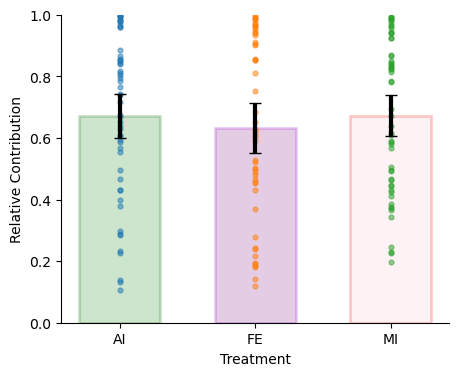

In [133]:
plt.figure(figsize=(5,4))
bars= plt.bar(
    summary["Treatment"],
    summary["mean"],
    yerr=summary["CI"],
    error_kw={
    "elinewidth":3,
    "capsize":4
    },
    alpha=0.2,
    width=0.6,
    color=["green","purple","pink"]
)
for bar, color in zip(
    bars,
    ["darkgreen","darkviolet","red"]
):
    bar.set_edgecolor(color)
    bar.set_linewidth(2)
for i,t in enumerate(summary["Treatment"]):
    values=(
        group_data[
            group_data["Treatment"]==t
        ]
        ["GroupRelativeContribution"]
    )
    plt.scatter(
    [i]*len(values),
    values,
    s=12,
    alpha=0.5
    )
plt.ylim(0,1)
plt.ylabel("Relative Contribution")
plt.xlabel("Treatment")
ax=plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig(
    output_dir/"figure_4a.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## figure-4B

In [134]:
round_summary=data.groupby(["Treatment","Round"])[["GroupRelativeContribution"]].mean().reset_index()

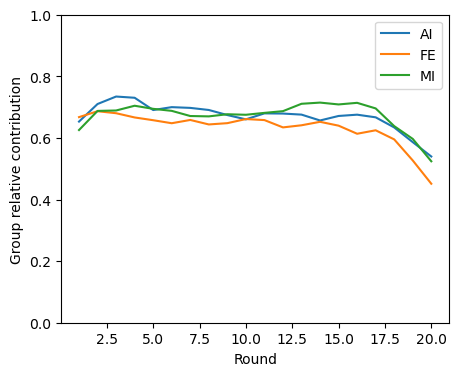

In [139]:
plt.figure(figsize=(5,4))
for group in round_summary["Treatment"].unique():
    temp=round_summary[round_summary["Treatment"]==group]
    plt.plot(
        temp["Round"],
        temp["GroupRelativeContribution"],
        label=group
    )
plt.ylim(0,1)
plt.xlabel("Round")
plt.ylabel("Group relative contribution")
plt.legend()
plt.savefig(
    output_dir/"figure_4b.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## figure-4C

In [136]:
summary_surplus=group_data.groupby("Treatment")["Surplus"].agg(["count","mean","std"])
summary_surplus = summary_surplus.reset_index()
summary_surplus["SE"]=summary_surplus["std"]/np.sqrt(summary_surplus["count"])
summary_surplus["CI"]=1.96*summary_surplus["SE"]

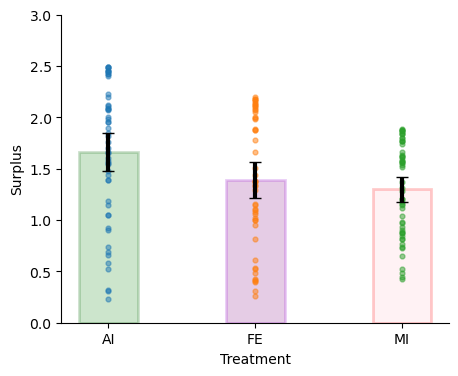

In [137]:
plt.figure(figsize=(5,4))
bars= plt.bar(
    summary_surplus["Treatment"],
    summary_surplus["mean"],
    yerr=summary_surplus["CI"],
    error_kw={
    "elinewidth":3,
    "capsize":4
    },
    alpha=0.2,
    width=0.4,
    color=["green","purple","pink"]
)
for bar, color in zip(
    bars,
    ["darkgreen","darkviolet","red"]
):
    bar.set_edgecolor(color)
    bar.set_linewidth(2)
for i,t in enumerate(summary_surplus["Treatment"]):
    values=(
        group_data[
            group_data["Treatment"]==t
        ]
        ["Surplus"]
    )
    plt.scatter(
    [i]*len(values),
    values,
    s=12,
    alpha=0.5
    )
plt.ylim(0,3)
plt.ylabel("Surplus")
plt.xlabel("Treatment")
ax=plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig(
    output_dir/"figure_4c.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()